In [ ]:
# Load CIFAR-10 image Dataset

from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('x_train shape :', x_train.shape)
print('y_train shape :', y_train.shape)
print('x_test  shape :', x_test.shape)
print('y_test  shape :', y_test.shape)
print('Pixel value range:', x_train.min(), '-', x_train.max())

c:\Users\airtel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


x_train shape : (50000, 32, 32, 3)
y_train shape : (50000, 1)
x_test  shape : (10000, 32, 32, 3)
y_test  shape : (10000, 1)
Pixel value range: 0 - 255


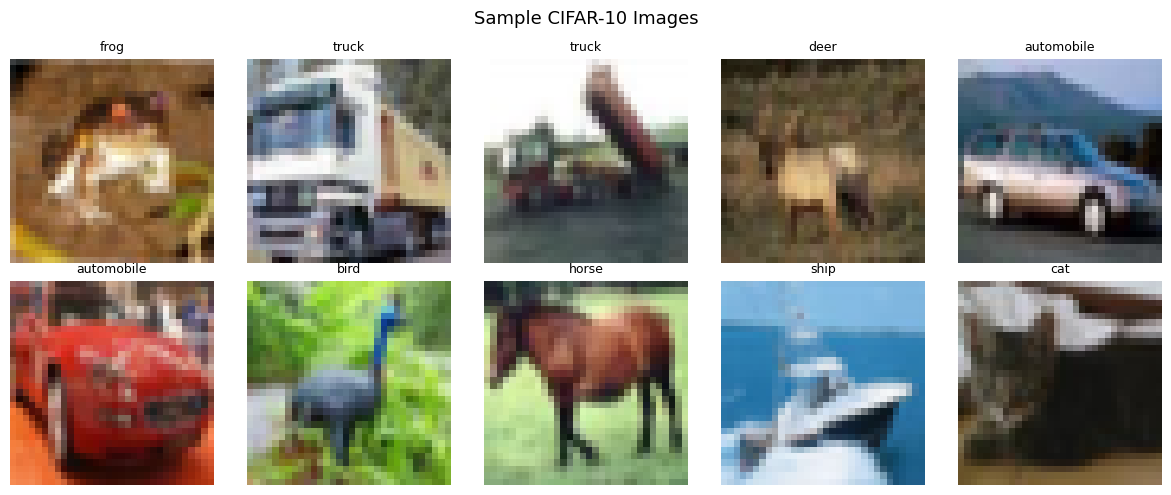

In [ ]:
# Visualizing sample images

import matplotlib.pyplot as plt

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12, 5))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[y_train[i][0]], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=13)
plt.tight_layout()
plt.show()

Number of classes     : 10
Total training images : 50000
Total test images     : 10000
Image size            : (32, 32, 3)

Images per class (train):
  airplane    : 5000
  automobile  : 5000
  bird        : 5000
  cat         : 5000
  deer        : 5000
  dog         : 5000
  frog        : 5000
  horse       : 5000
  ship        : 5000
  truck       : 5000


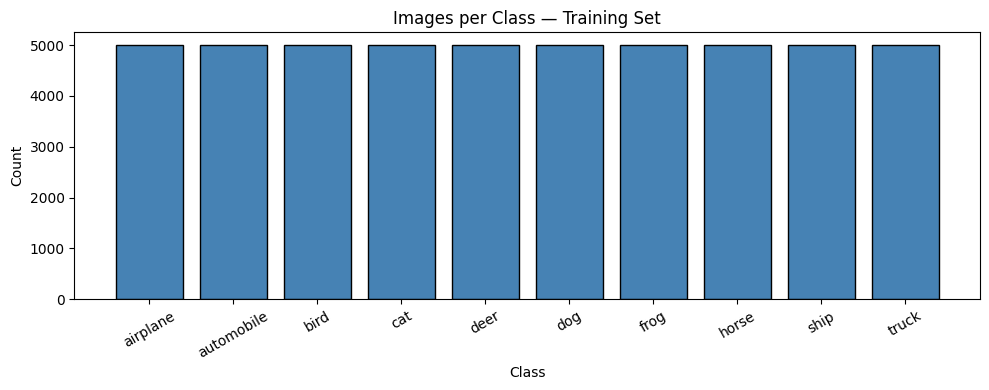

In [ ]:
# Data Exploration

import numpy as np

print(f'Number of classes     : {len(CLASS_NAMES)}')
print(f'Total training images : {x_train.shape[0]}')
print(f'Total test images     : {x_test.shape[0]}')
print(f'Image size            : {x_train.shape[1:]}')
print()

unique, counts = np.unique(y_train, return_counts=True)
print('Images per class (train):')
for cls_id, cnt in zip(unique, counts):
    print(f'  {CLASS_NAMES[cls_id]:12s}: {cnt}')

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black')
plt.title('Images per Class — Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

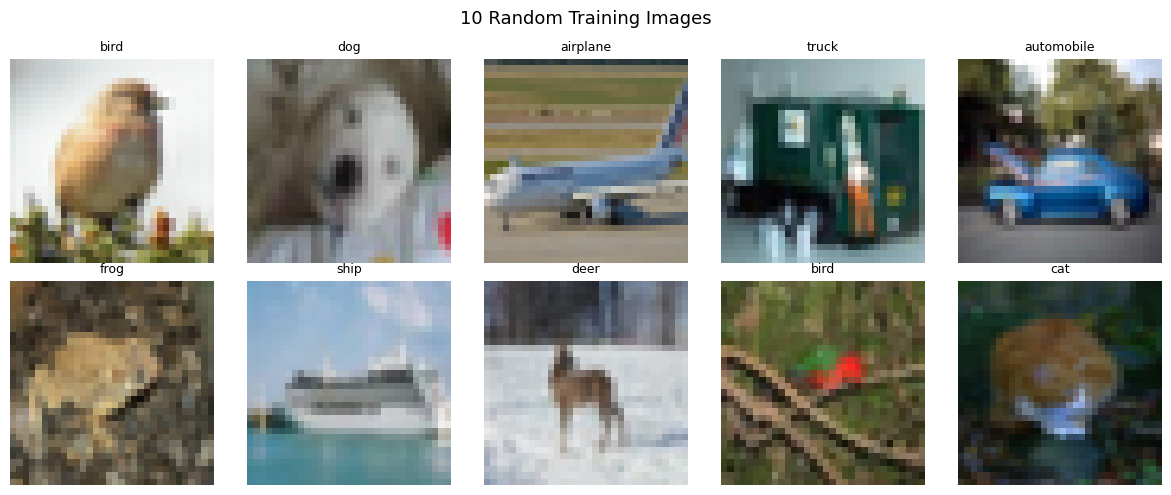

In [ ]:
# Visualize 10 random images

import random

indices = random.sample(range(len(x_train)), 10)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx])
    plt.title(CLASS_NAMES[y_train[idx][0]], fontsize=9)
    plt.axis('off')
plt.suptitle('10 Random Training Images', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
from tensorflow.keras.utils import to_categorical

# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print('After normalization — min:', x_train_norm.min(), ' max:', x_train_norm.max())

# One-hot encode labels
NUM_CLASSES = 10
y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = to_categorical(y_test,  NUM_CLASSES)

print('y_train_ohe shape:', y_train_ohe.shape)
print('y_test_ohe  shape:', y_test_ohe.shape)

After normalization — min: 0.0  max: 1.0
y_train_ohe shape: (50000, 10)
y_test_ohe  shape: (10000, 10)


Augmentation applied: rotation, horizontal flip, zoom


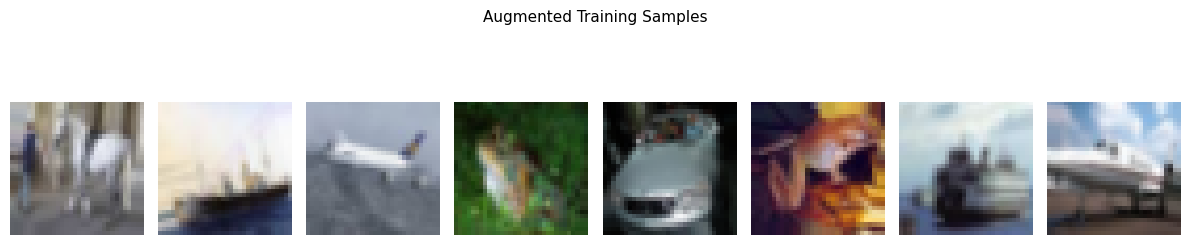

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,      # augmentation 1: rotation
    horizontal_flip=True,   # augmentation 2: horizontal flip
    zoom_range=0.1          # augmentation 3: zoom
)
train_datagen.fit(x_train_norm)

BATCH_SIZE = 64
train_generator = train_datagen.flow(x_train_norm, y_train_ohe, batch_size=BATCH_SIZE, seed=42)

print('Augmentation applied: rotation, horizontal flip, zoom')

# Visualize a few augmented samples
aug_batch, _ = next(train_generator)
plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(aug_batch[i])
    plt.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Baseline CNN — trained from scratch on CIFAR-10

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='Baseline_CNN')

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

c:\Users\airtel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
EPOCHS = 50

from tensorflow.keras.callbacks import EarlyStopping

early_stop_baseline = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
early_stop_tl = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history_baseline = baseline_model.fit(
    train_generator,
    steps_per_epoch=len(x_train_norm) // BATCH_SIZE,
    validation_data=(x_test_norm, y_test_ohe),
    epochs=EPOCHS,
    verbose=1,
    callbacks=[early_stop_baseline]
)


Epoch 1/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.4092 - loss: 1.6123 - val_accuracy: 0.4892 - val_loss: 1.3777
Epoch 2/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4375 - loss: 1.3955

c:\Users\airtel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4375 - loss: 1.3955 - val_accuracy: 0.5004 - val_loss: 1.3544
Epoch 3/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5545 - loss: 1.2452 - val_accuracy: 0.6415 - val_loss: 1.0174
Epoch 4/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6562 - loss: 0.9875 - val_accuracy: 0.6374 - val_loss: 1.0266
Epoch 5/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6118 - loss: 1.0987 - val_accuracy: 0.6732 - val_loss: 0.9354
Epoch 6/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6719 - loss: 0.9800 - val_accuracy: 0.6802 - val_loss: 0.9203
Epoch 7/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6479 - loss: 1.0026 - val_accuracy: 0.6851 - val_loss: 0.8937
Epoch 8/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6719 - loss: 0.8126 - val_accuracy: 0.6866 - val_loss: 0.8881
Epoch 9/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6721 - loss: 0.9390 - val_accuracy: 0.704

In [ ]:
# Using Transfer Learning for train

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
import tensorflow as tf

# Resize images to 96x96 for MobileNetV2 (works better than 32x32)
x_train_resized = tf.image.resize(x_train_norm, (96, 96)).numpy()
x_test_resized  = tf.image.resize(x_test_norm,  (96, 96)).numpy()

# Augmentation generator for resized images
tl_datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)
tl_datagen.fit(x_train_resized)
tl_train_generator = tl_datagen.flow(x_train_resized, y_train_ohe, batch_size=BATCH_SIZE, seed=42)

# Load MobileNetV2 with frozen base
base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Add custom classification head
inputs  = tf.keras.Input(shape=(96, 96, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_Transfer')
tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(f'Trainable params : {sum([tf.size(w).numpy() for w in tl_model.trainable_weights]):,}')
print(f'Frozen params    : {sum([tf.size(w).numpy() for w in tl_model.non_trainable_weights]):,}')

Trainable params : 165,258
Frozen params    : 2,257,984


In [20]:
history_tl = tl_model.fit(
    tl_train_generator,
    steps_per_epoch=len(x_train_resized) // BATCH_SIZE,
    validation_data=(x_test_resized, y_test_ohe),
    epochs=EPOCHS,
    verbose=1,
    callbacks=[early_stop_tl]
)

Epoch 1/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 121s 148ms/step - accuracy: 0.6607 - loss: 0.9741 - val_accuracy: 0.7784 - val_loss: 0.6426
Epoch 2/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7031 - loss: 0.8486 - val_accuracy: 0.7794 - val_loss: 0.6419
Epoch 3/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.7233 - loss: 0.7910 - val_accuracy: 0.7875 - val_loss: 0.6131
Epoch 4/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7344 - loss: 0.7205 - val_accuracy: 0.7852 - val_loss: 0.6165
Epoch 5/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.7397 - loss: 0.7443 - val_accuracy: 0.7962 - val_loss: 0.5911
Epoch 6/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6719 - loss: 0.9151 - val_accuracy: 0.7951 - val_loss: 0.5913
Epoch 7/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 112s 143ms/step - accuracy: 0.7521 - loss: 0.7141 - val_accuracy: 0.8004 - val_loss: 0.5773
Epoch 8/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7344 - loss: 0

In [23]:
# Predictions for Baseline Model
y_pred_baseline = baseline_model.predict(x_test_norm)
y_pred_baseline_classes = y_pred_baseline.argmax(axis=1)

# Predictions for Transfer Learning Model
y_pred_tl = tl_model.predict(x_test_resized)
y_pred_tl_classes = y_pred_tl.argmax(axis=1)

# True labels
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step


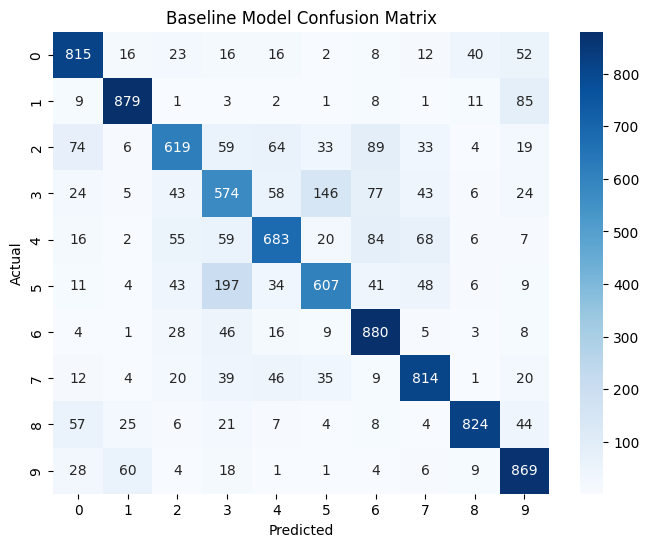

Baseline Model Classification Report:

              precision    recall  f1-score   support

    airplane       0.78      0.81      0.80      1000
  automobile       0.88      0.88      0.88      1000
        bird       0.74      0.62      0.67      1000
         cat       0.56      0.57      0.56      1000
        deer       0.74      0.68      0.71      1000
         dog       0.71      0.61      0.65      1000
        frog       0.73      0.88      0.80      1000
       horse       0.79      0.81      0.80      1000
        ship       0.91      0.82      0.86      1000
       truck       0.76      0.87      0.81      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.75     10000
weighted avg       0.76      0.76      0.75     10000



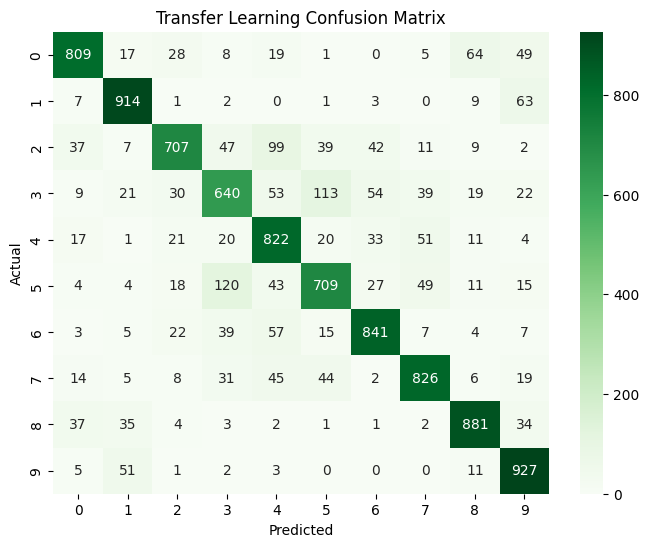

Transfer Learning Classification Report:

              precision    recall  f1-score   support

    airplane       0.86      0.81      0.83      1000
  automobile       0.86      0.91      0.89      1000
        bird       0.84      0.71      0.77      1000
         cat       0.70      0.64      0.67      1000
        deer       0.72      0.82      0.77      1000
         dog       0.75      0.71      0.73      1000
        frog       0.84      0.84      0.84      1000
       horse       0.83      0.83      0.83      1000
        ship       0.86      0.88      0.87      1000
       truck       0.81      0.93      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion Matrix - Baseline
cm_baseline = confusion_matrix(y_true, y_pred_baseline_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report - Baseline
print("Baseline Model Classification Report:\n")
print(classification_report(y_true, y_pred_baseline_classes, target_names=CLASS_NAMES))


# Confusion Matrix - Transfer Learning
cm_tl = confusion_matrix(y_true, y_pred_tl_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens')
plt.title('Transfer Learning Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report - Transfer Learning
print("Transfer Learning Classification Report:\n")
print(classification_report(y_true, y_pred_tl_classes, target_names=CLASS_NAMES))

In [ ]:
# Final Accuracy Comparison

# Evaluate Baseline Model
baseline_loss, baseline_acc = baseline_model.evaluate(x_test_norm, y_test_ohe, verbose=0)

# Evaluate Transfer Learning Model
tl_loss, tl_acc = tl_model.evaluate(x_test_resized, y_test_ohe, verbose=0)

print(f"Baseline Model Accuracy        : {baseline_acc:.4f}")
print(f"Transfer Learning Accuracy     : {tl_acc:.4f}")

if tl_acc > baseline_acc:
    print("\nTransfer Learning performs better.")
else:
    print("\nBaseline model performs better.")

Baseline Model Accuracy        : 0.7564
Transfer Learning Accuracy     : 0.8076

Transfer Learning performs better.


## Interpretation & Reflection

### 1. How pretrained CNNs help extract useful features

Pretrained CNN models like MobileNetV2 are trained on large datasets such as ImageNet. They learn general features like edges, textures and shapes in early layers and more complex patterns in deeper layers. These learned features can be reused for new tasks like CIFAR-10 classification, improving performance and reducing training time.

### 2. Why is transfer learning useful for small datasets?

Transfer learning is useful for small datasets because the model already has prior knowledge from large datasets. Instead of learning from scratch, it adapts existing features, which helps avoid overfitting and improves accuracy even with limited data.

### 3. What happens if pretrained layers are not frozen?

If pretrained layers are not frozen, their weights will be updated during training. This may lead to overfitting, especially on small datasets, and can destroy useful pre-learned features also called Catastrophic Forgetting. 

### 4. When can transfer learning perform worse than training from scratch?

Transfer learning can perform worse when the source dataset (like ImageNet) is very different from the target dataset. In such cases, learned features may not be relevant, and training from scratch might perform better. For example, MobileNetV2 is trained on natural photos and if we use this model with datasets something like X-ray scans or satellite images, then transfer learning may not perform well. 
